# Supply Chain Shipment Delay Prediction
## Data Preprocessing & Feature Engineering — SCMS + LPI Merged Dataset

**Course:** Machine Learning and Pattern Recognition  
**Dataset:** SCMS Delivery History Dataset enriched with World Bank LPI scores  
(10,324 shipment records × 33 SCMS variables + 8 LPI columns)

The merged dataset allows shipment-level operational data to be analyzed alongside broader logistics environment indicators for the corresponding countries.


### Purpose of the Notebook
This notebook performs the **complete pre-processing pipeline** required before modelling. The goal is to produce a clean, analysis-ready dataset that integrates shipment-level SCMS variables with country-level LPI indicators.


### Notebook Structure
1. Load & Initial Inspection
2. Data Cleaning
3. Target Variable Engineering
4. Exploratory Data Analysis (extended)
5. Feature Engineering
6. Encoding & Normalisation
7. Final Dataset Summary & Export

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load & Initial Inspection

In [29]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH  = '/content/drive/MyDrive/Semester 4/MLPR/MLPR Project/scms_lpi_emdat_merged.csv'
OUTPUT_DIR = '/content/drive/MyDrive/Semester 4/MLPR/MLPR Project'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# Fix BOM in column name if present (can appear when CSV saved on Windows)
df.columns = [c.lstrip('\ufeff') for c in df.columns]

print(f'Shape: {df.shape}')
df.head(3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (10324, 47)


,ï»¿ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD),shipment_year,delay_days,is_delayed,lead_time_days,country_lpi,lpi_year_used,lpi_score,lpi_customs,lpi_infrastructure,lpi_intl_shipments,lpi_logistics_quality,lpi_tracking,lpi_timeliness,Disaster_Severity_Index
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,NaN,2006-06-02,2006-06-02,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.0,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN,2006,0,0,NaN,Côte d'Ivoire,2007,2.361346,2.22222,2.22222,2.125,2.375,2.0,3.25,0.000000
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Viet Nam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,NaN,2006-11-14,2006-11-14,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.2,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN,2006,0,0,NaN,Viet Nam,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.232869
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,NaN,2006-08-27,2006-08-27,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.0,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN,2006,0,0,NaN,Côte d'Ivoire,2007,2.361346,2.22222,2.22222,2.125,2.375,2.0,3.25,0.000000


In [30]:
print("Loaded:", len(df))

# After date parsing
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date',
             'Scheduled Delivery Date', 'Delivered to Client Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
print("After date parse:", len(df))
print("NaT counts:")
for col in date_cols:
    print(f"  {col}: {df[col].isnull().sum()}")

# After scheduled delivery drop
before = len(df)
df.dropna(subset=['Scheduled Delivery Date'], inplace=True)
print(f"After dropna Scheduled: {len(df)} (dropped {before - len(df)})")

# After delivered date drop
before = len(df)
df.dropna(subset=['Delivered to Client Date'], inplace=True)
print(f"After dropna Delivered: {len(df)} (dropped {before - len(df)})")

Loaded: 10324
After date parse: 10324
NaT counts:
  PQ First Sent to Client Date: 2681
  PO Sent to Vendor Date: 5732
  Scheduled Delivery Date: 0
  Delivered to Client Date: 0
After dropna Scheduled: 10324 (dropped 0)
After dropna Delivered: 10324 (dropped 0)


In [31]:
print('Column dtypes:')
print(df.dtypes)
print('\nMissing value counts:')
missing = df.isnull().sum()
print(missing[missing > 0])

Column dtypes:
ï»¿ID                                    int64
Project Code                            object
PQ #                                    object
PO / SO #                               object
ASN/DN #                                object
Country                                 object
Managed By                              object
Fulfill Via                             object
Vendor INCO Term                        object
Shipment Mode                           object
PQ First Sent to Client Date    datetime64[ns]
PO Sent to Vendor Date          datetime64[ns]
Scheduled Delivery Date         datetime64[ns]
Delivered to Client Date        datetime64[ns]
Delivery Recorded Date                  object
Product Group                           object
Sub Classification                      object
Vendor                                  object
Item Description                        object
Molecule/Test Type                      object
Brand                                   objec

In [32]:
# LPI columns kept after dropping lpi_score and lpi_intl_shipments
LPI_COLS = [
    'lpi_customs',          # customs & border management efficiency
    'lpi_infrastructure',   # trade & transport infrastructure quality
    'lpi_logistics_quality',# logistics services competence
    'lpi_tracking',         # tracking & tracing capability
    'lpi_timeliness',       # on-time delivery frequency
]

print('LPI column coverage (non-null rows):')
for c in LPI_COLS:
    n_null = df[c].isnull().sum()
    pct    = n_null / len(df) * 100
    print(f'  {c:35s}  missing: {n_null:5d}  ({pct:.1f}%)')

no_lpi = df[df['lpi_customs'].isnull()]['Country'].unique()
print(f'\nCountries with no LPI data ({len(no_lpi)}): {sorted(no_lpi)}')


LPI column coverage (non-null rows):
  lpi_customs                          missing:  2302  (22.3%)
  lpi_infrastructure                   missing:  2302  (22.3%)
  lpi_logistics_quality                missing:  2302  (22.3%)
  lpi_tracking                         missing:  2302  (22.3%)
  lpi_timeliness                       missing:  2302  (22.3%)

Countries with no LPI data (12): ['Belize', 'Botswana', 'Eswatini', 'Mali', 'Mozambique', 'Sierra Leone', 'South Sudan', 'Uganda', 'United Republic of Tanzania', 'Viet Nam', 'Zambia', 'Zimbabwe']


## 2. Data Cleaning

### 2a. Parse Dates

Convert the four key date columns from string to `datetime`. Non-parseable values (e.g. `'Date Not Captured'`, `'Pre-PQ Process'`) are coerced to `NaT`.

In [33]:
date_cols = [
    'PQ First Sent to Client Date',
    'PO Sent to Vendor Date',
    'Scheduled Delivery Date',
    'Delivered to Client Date'
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

print('Date parsing done. NaT counts:')
for col in date_cols:
    print(f'  {col}: {df[col].isnull().sum()}')

Date parsing done. NaT counts:
  PQ First Sent to Client Date: 2681
  PO Sent to Vendor Date: 5732
  Scheduled Delivery Date: 0
  Delivered to Client Date: 0


### 2b. Drop Identifier / Leakage Columns

The following columns are either unique identifiers (no predictive value) or would cause target leakage:
- `ID`, `Project Code`, `PQ #`, `PO / SO #`, `ASN/DN #` — administrative identifiers.
- `Delivered to Client Date`, `Delivery Recorded Date` — these encode the outcome directly.
- `delay_days` if present — direct leakage.
- `lpi_year_used` — administrative; redundant once LPI scores are present.
- `Dosage`, `Brand`, `Molecule/Test Type`, `Item Description`, `Manufacturing Site` — free-text / very high cardinality; low signal-to-noise for tabular ML.

In [34]:
# Columns to drop:
# - Identifiers: ID (BOM-safe), Project Code, PQ#, PO/SO#, ASN/DN#
# - Leakage/outcome: Delivery Recorded Date
# - Pre-computed in merge (will recompute cleanly here):
#     delay_days, is_delayed, shipment_year, lead_time_days
# - Redundant LPI: lpi_score (overall index — sub-dimensions kept instead),
#                  lpi_intl_shipments (dropped per project spec),
#                  lpi_year_used, country_lpi (join keys, not features)
# - High-cardinality free text: Dosage, Brand, Molecule/Test Type,
#                               Item Description, Manufacturing Site
drop_cols = [
    'ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #',
    'Delivery Recorded Date',
    'delay_days', 'is_delayed', 'shipment_year', 'lead_time_days',
    'lpi_score', 'lpi_intl_shipments', 'lpi_year_used', 'country_lpi',
    'Dosage', 'Brand', 'Molecule/Test Type', 'Item Description', 'Manufacturing Site',
]
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'Columns after drop: {df.shape[1]}')
print(df.columns.tolist())


Columns after drop: 29
['ï»¿ID', 'Country', 'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'PQ First Sent to Client Date', 'PO Sent to Vendor Date', 'Scheduled Delivery Date', 'Delivered to Client Date', 'Product Group', 'Sub Classification', 'Vendor', 'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Insurance (USD)', 'lpi_customs', 'lpi_infrastructure', 'lpi_logistics_quality', 'lpi_tracking', 'lpi_timeliness', 'Disaster_Severity_Index']


### 2c. Coerce Numeric Columns

`Weight (Kilograms)` and `Freight Cost (USD)` sometimes contain string values like `'See Comments'`. Force them to numeric, pushing non-numeric entries to NaN for later imputation.

In [35]:
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

print('Weight nulls after coercion:', df['Weight (Kilograms)'].isnull().sum())
print('Freight Cost nulls after coercion:', df['Freight Cost (USD)'].isnull().sum())

Weight nulls after coercion: 3952
Freight Cost nulls after coercion: 4126


### 2d. Handle Missing Values

- **Shipment Mode:** Impute with mode (`'Air'` is dominant).
- **Weight & Freight Cost:** Impute with median (robust to outliers).
- **Line Item Insurance:** Treat NaN as 0 — missing insurance likely means no insurance was charged.
- **LPI columns:** ~8 countries had no LPI data across any survey year. Impute with the column-wise median across all other countries. These rows are flagged with a binary `lpi_missing` indicator feature.
- **Rows with unparseable Scheduled/Delivered dates:** Drop — the target variable cannot be computed.

In [36]:
before = len(df)
df.dropna(subset=['Scheduled Delivery Date'], inplace=True)
print(f'Rows dropped (missing Scheduled Delivery Date): {before - len(df)}')

df['Shipment Mode'].fillna(df['Shipment Mode'].mode()[0], inplace=True)
df['Weight (Kilograms)'].fillna(df['Weight (Kilograms)'].median(), inplace=True)
df['Freight Cost (USD)'].fillna(df['Freight Cost (USD)'].median(), inplace=True)
df['Line Item Insurance (USD)'].fillna(0, inplace=True)
df['Disaster_Severity_Index'].fillna(0, inplace=True)

# Drop rows for countries with no LPI data across any survey year
before = len(df)
df.dropna(subset=['lpi_customs'], inplace=True)
print(f'Rows dropped (no LPI coverage): {before - len(df)} ({(before - len(df))/before*100:.1f}%)')
print(f'Rows remaining: {len(df)}')

print('\nRemaining missing values (excluding date columns):')
remaining = df.drop(columns=date_cols, errors='ignore').isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else 'None — all clean!')


Rows dropped (missing Scheduled Delivery Date): 0
Rows dropped (no LPI coverage): 2302 (22.3%)
Rows remaining: 8022

Remaining missing values (excluding date columns):
None — all clean!


### 2e. Winsorise Outliers in Key Numeric Features

Cap extreme values at the 99th percentile to prevent them from dominating distance-based and linear models. Winsorisation is preferred over row-dropping to preserve dataset size.

In [37]:
winsorise_cols = ['Weight (Kilograms)', 'Freight Cost (USD)', 'Line Item Quantity', 'Line Item Value']
for col in winsorise_cols:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)
    print(f'{col}: capped at {upper:.2f}')

Weight (Kilograms): capped at 26259.99
Freight Cost (USD): capped at 64672.02
Line Item Quantity: capped at 190798.69
Line Item Value: capped at 1516474.72


## 3. Target Variable Engineering

Compute `delay_days = Delivered to Client Date - Scheduled Delivery Date`. A shipment is labelled **delayed (1)** if it arrived **more than 0 days late**. On-time or early shipments are labelled **0**.

> In healthcare logistics, even a 1-day delay is operationally significant — we use >0 as the threshold. Rows with missing `Delivered to Client Date` are dropped here.

In [38]:
DELAY_THRESHOLD_DAYS = 0

before = len(df)
df.dropna(subset=['Delivered to Client Date'], inplace=True)
print(f'Rows dropped (missing Delivered to Client Date): {before - len(df)}')

df['delay_days'] = (df['Delivered to Client Date'] - df['Scheduled Delivery Date']).dt.days
df['is_delayed']  = (df['delay_days'] > DELAY_THRESHOLD_DAYS).astype(int)

# Drop the raw outcome date now that target is built
# (delay_days kept temporarily for the visualisation in the next cell)
df.drop(columns=['Delivered to Client Date'], inplace=True)

print('Class balance:')
print(df['is_delayed'].value_counts(normalize=True).rename({0: 'On-Time', 1: 'Delayed'}))
print(f'\nDelay days stats:')
print(df['delay_days'].describe())

Rows dropped (missing Delivered to Client Date): 0
Class balance:
is_delayed
On-Time    0.883446
Delayed    0.116554
Name: proportion, dtype: float64

Delay days stats:
count    8022.000000
mean       -6.607953
std        29.117387
min      -372.000000
25%        -4.000000
50%         0.000000
75%         0.000000
max       192.000000
Name: delay_days, dtype: float64


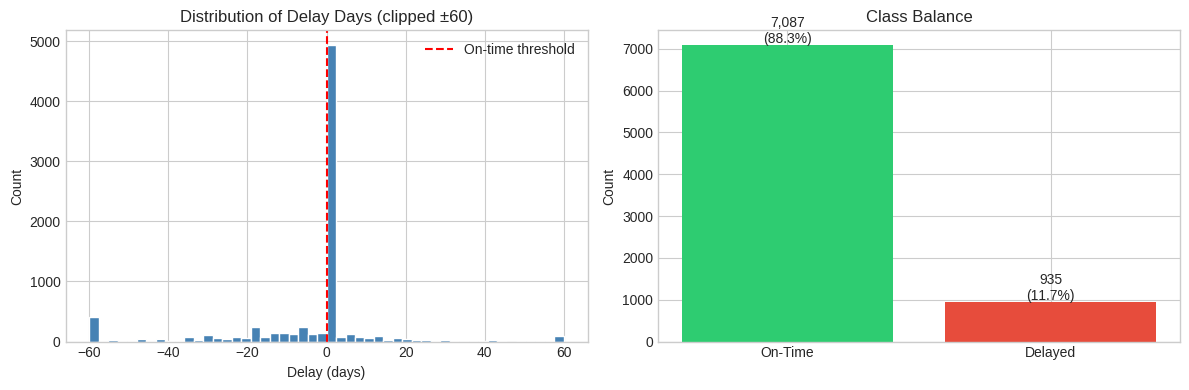

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Delay days histogram (clipped for readability)
clip_days = df['delay_days'].clip(-60, 60)
axes[0].hist(clip_days.dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='On-time threshold')
axes[0].set_title('Distribution of Delay Days (clipped ±60)')
axes[0].set_xlabel('Delay (days)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class balance bar
counts = df['is_delayed'].value_counts().sort_index()
labels = ['On-Time', 'Delayed']
axes[1].bar(labels, counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Class Balance')
axes[1].set_ylabel('Count')
for i, val in enumerate(counts.values):
    axes[1].text(i, val + 50, f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

# Drop delay_days now — not needed beyond this point
df.drop(columns=['delay_days'], inplace=True)

## 4. Exploratory Data Analysis

This section is expanded compared to the original SCMS-only notebook. We now include:
- SCMS categorical breakdowns (delay rate by shipment mode, product group, country)
- **LPI score distributions across countries**
- **Delay rate by LPI tier** (low / medium / high)
- **Correlation heatmap** including LPI columns vs delay
- **LPI sub-dimension pairplot** coloured by delay label

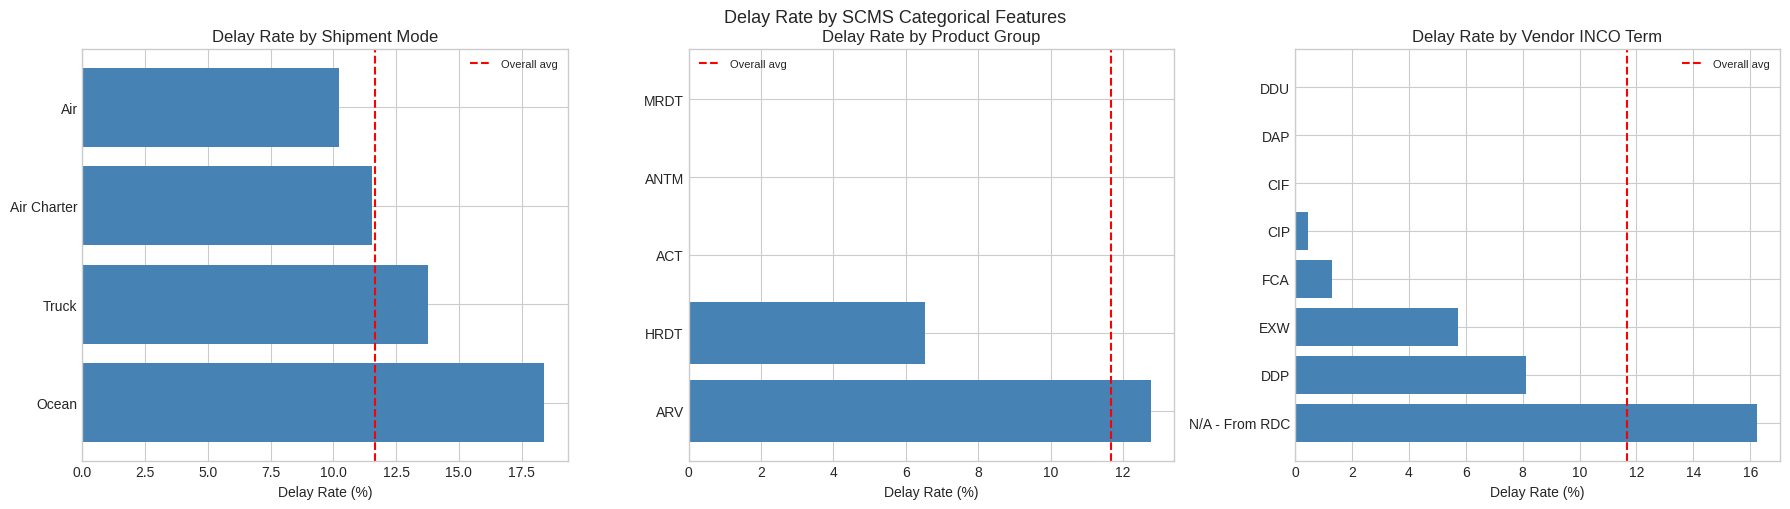

In [40]:
# --- Delay rate by Shipment Mode, Product Group, Vendor INCO Term ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Shipment Mode', 'Product Group', 'Vendor INCO Term']):
    rates = df.groupby(col)['is_delayed'].mean().sort_values(ascending=False)
    ax.barh(rates.index, rates.values * 100, color='steelblue')
    ax.set_xlabel('Delay Rate (%)')
    ax.set_title(f'Delay Rate by {col}')
    ax.axvline(df['is_delayed'].mean() * 100, color='red', linestyle='--', label='Overall avg')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Delay Rate by SCMS Categorical Features', y=1.01, fontsize=13)
plt.show()

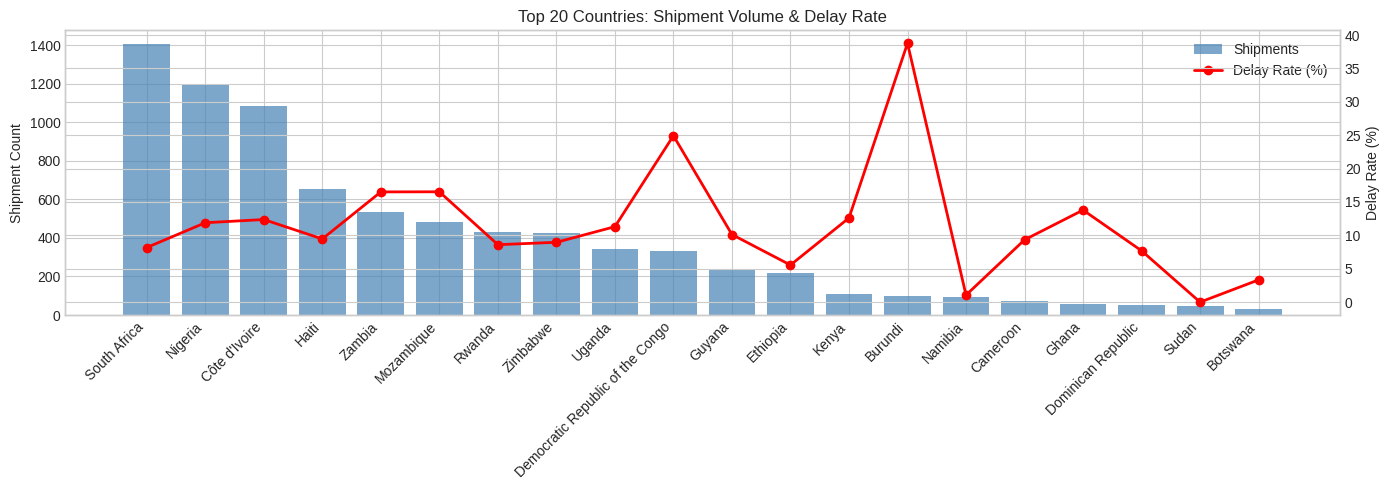

In [41]:
# Top 20 countries by shipment volume with delay rate overlay
country_stats = df.groupby('Country').agg(
    shipments=('is_delayed', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_timeliness=('lpi_timeliness', 'mean')
).sort_values('shipments', ascending=False).head(20)

fig, ax1 = plt.subplots(figsize=(14, 5))
x = range(len(country_stats))
ax1.bar(x, country_stats['shipments'], color='steelblue', alpha=0.7, label='Shipments')
ax1.set_xticks(x)
ax1.set_xticklabels(country_stats.index, rotation=45, ha='right')
ax1.set_ylabel('Shipment Count')
ax2 = ax1.twinx()
ax2.plot(x, country_stats['delay_rate'] * 100, 'ro-', label='Delay Rate (%)', linewidth=2)
ax2.set_ylabel('Delay Rate (%)')
ax1.set_title('Top 20 Countries: Shipment Volume & Delay Rate')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()


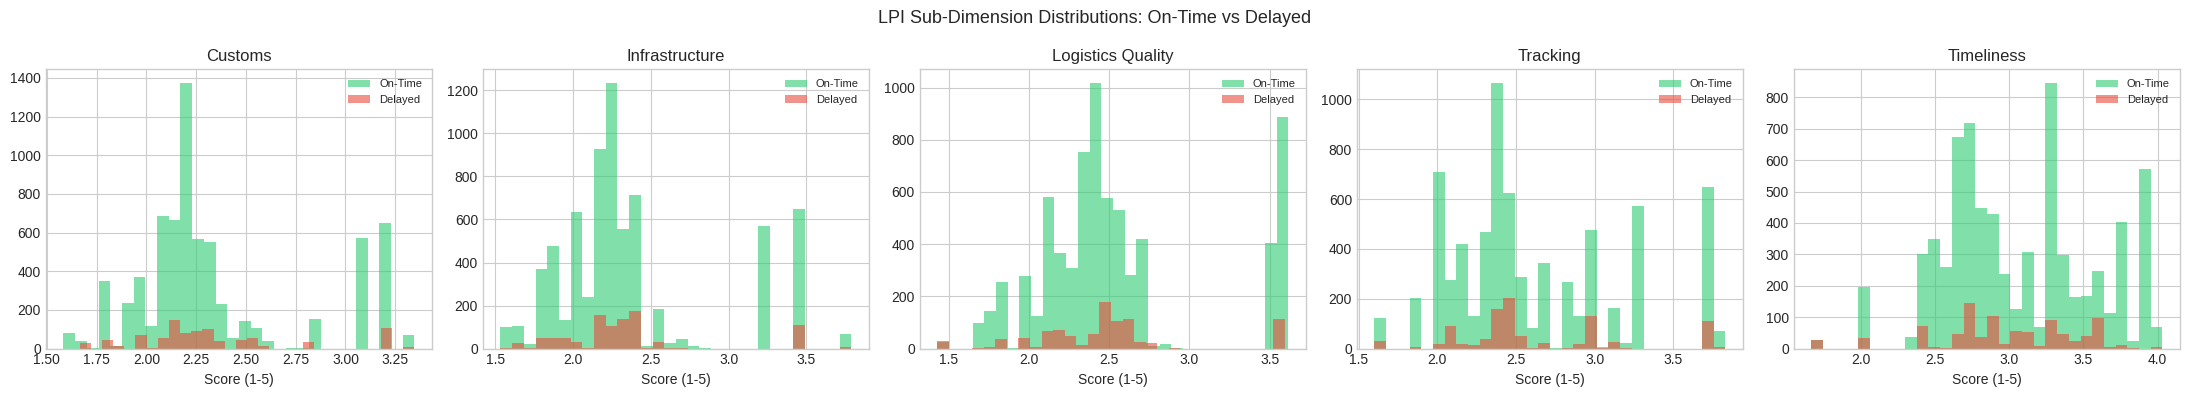

In [42]:
# LPI score distributions: on-time vs delayed (5 sub-dimensions)
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, col in zip(axes, LPI_COLS):
    ax.hist(df[df['is_delayed'] == 0][col], bins=30, alpha=0.6, color='#2ecc71', label='On-Time')
    ax.hist(df[df['is_delayed'] == 1][col], bins=30, alpha=0.6, color='#e74c3c', label='Delayed')
    ax.set_title(col.replace('lpi_', '').replace('_', ' ').title())
    ax.set_xlabel('Score (1-5)')
    ax.legend(fontsize=8)

plt.suptitle('LPI Sub-Dimension Distributions: On-Time vs Delayed', fontsize=13)
plt.tight_layout()
plt.show()


Delay rate by LPI Timeliness tier:
          shipments  delay_rate  avg_timeliness
lpi_tier                                       
Low            2688       0.113           2.536
Medium         2680       0.129           3.007
High           2654       0.107           3.614


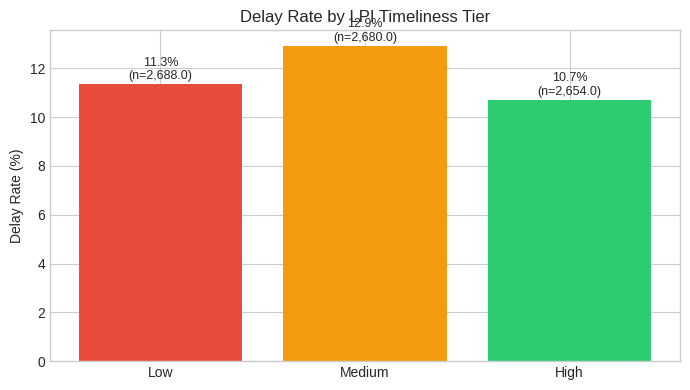

In [43]:
# Delay rate by LPI timeliness tier (most directly relevant sub-dimension)
try:
    df['lpi_tier'] = pd.qcut(df['lpi_timeliness'], q=3,
                              labels=['Low', 'Medium', 'High'],
                              duplicates='drop')
except ValueError:
    df['lpi_tier'] = pd.cut(df['lpi_timeliness'], bins=3,
                             labels=['Low', 'Medium', 'High'])

tier_stats = df.groupby('lpi_tier', observed=True).agg(
    shipments=('is_delayed', 'count'),
    delay_rate=('is_delayed', 'mean'),
    avg_timeliness=('lpi_timeliness', 'mean')
)
print('Delay rate by LPI Timeliness tier:')
print(tier_stats.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(tier_stats.index, tier_stats['delay_rate'] * 100,
              color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by LPI Timeliness Tier')
for bar, (_, row) in zip(bars, tier_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{row["delay_rate"]*100:.1f}%\n(n={row["shipments"]:,})',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()


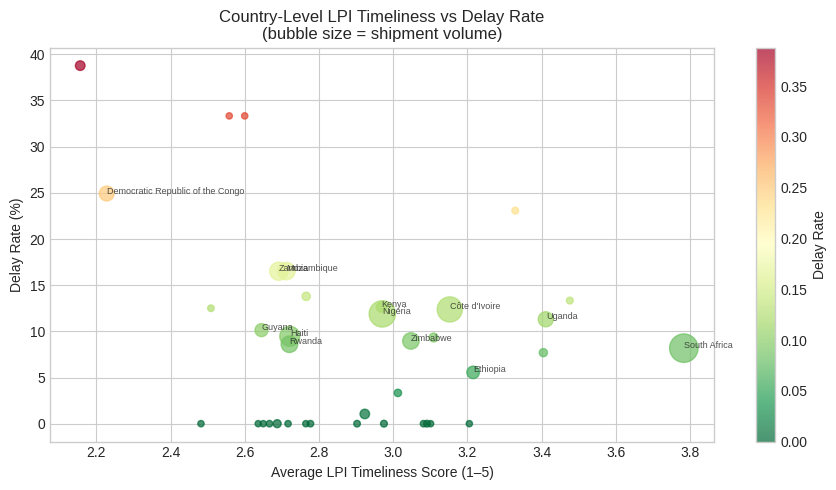

Pearson correlation (country-level lpi_timeliness vs delay_rate): -0.291


In [44]:
# Country-level LPI timeliness vs delay rate scatter
country_lpi = df.groupby('Country').agg(
    delay_rate=('is_delayed', 'mean'),
    lpi_timeliness=('lpi_timeliness', 'mean'),
    n=('is_delayed', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(country_lpi['lpi_timeliness'], country_lpi['delay_rate'] * 100,
                     s=country_lpi['n'] / country_lpi['n'].max() * 400 + 20,
                     alpha=0.7, c=country_lpi['delay_rate'], cmap='RdYlGn_r')
for _, row in country_lpi[country_lpi['n'] > 100].iterrows():
    ax.annotate(row['Country'], (row['lpi_timeliness'], row['delay_rate']*100),
                fontsize=6.5, alpha=0.8)
ax.set_xlabel('Average LPI Timeliness Score (1–5)')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Country-Level LPI Timeliness vs Delay Rate\n(bubble size = shipment volume)')
plt.colorbar(scatter, ax=ax, label='Delay Rate')
plt.tight_layout()
plt.show()

corr_val = country_lpi[['lpi_timeliness', 'delay_rate']].corr().iloc[0, 1]
print(f'Pearson correlation (country-level lpi_timeliness vs delay_rate): {corr_val:.3f}')


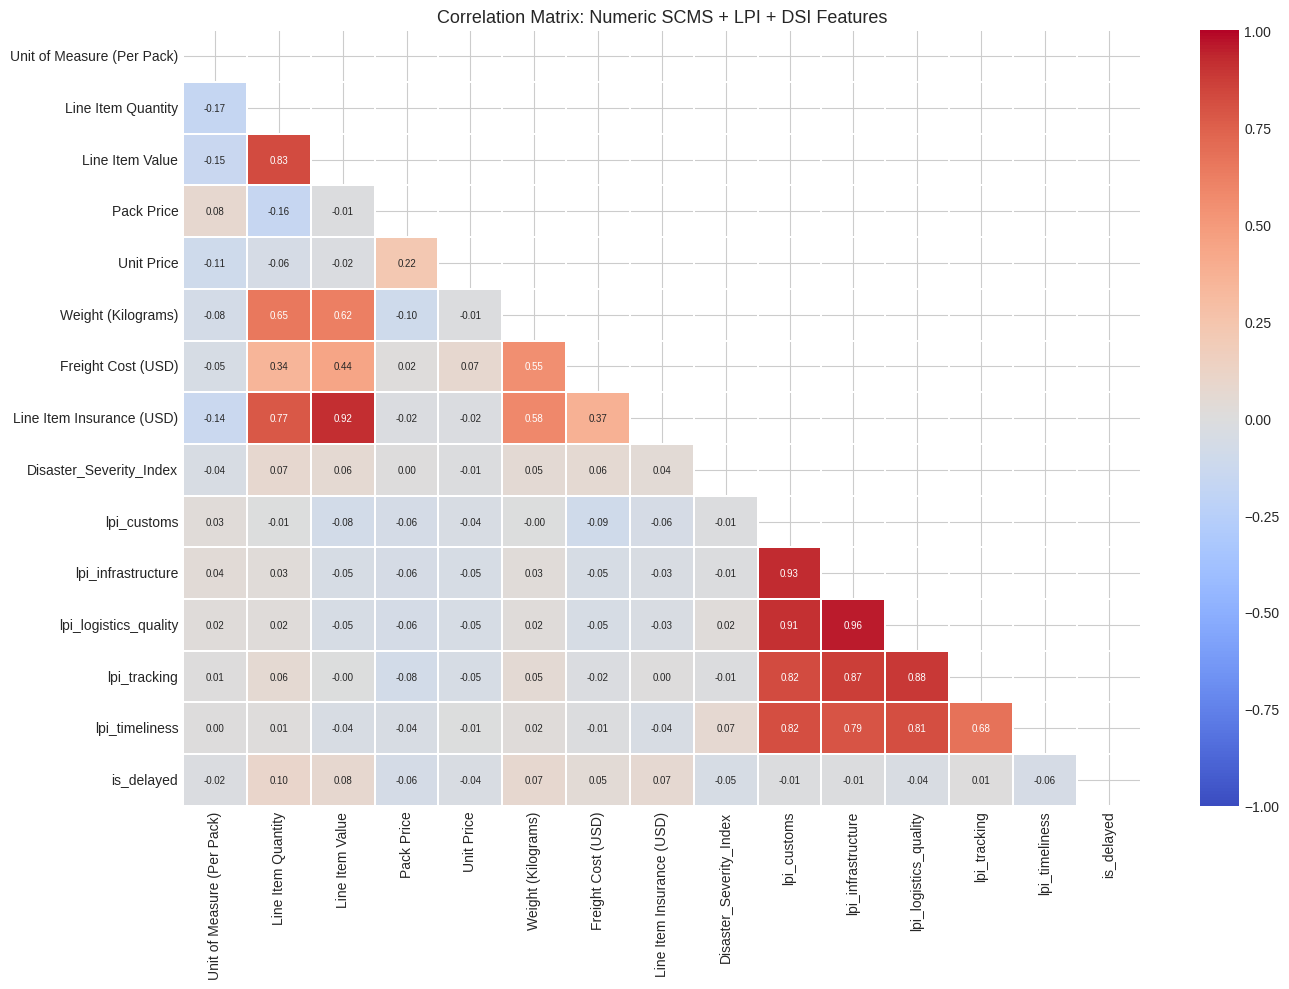

In [45]:
# Correlation heatmap: numeric SCMS + LPI sub-dimensions + DSI vs is_delayed
numeric_eda = [
    'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value',
    'Pack Price', 'Unit Price', 'Weight (Kilograms)', 'Freight Cost (USD)',
    'Line Item Insurance (USD)', 'Disaster_Severity_Index'
] + LPI_COLS + ['is_delayed']

corr_matrix = df[numeric_eda].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title('Correlation Matrix: Numeric SCMS + LPI + DSI Features', fontsize=13)
plt.tight_layout()
plt.show()


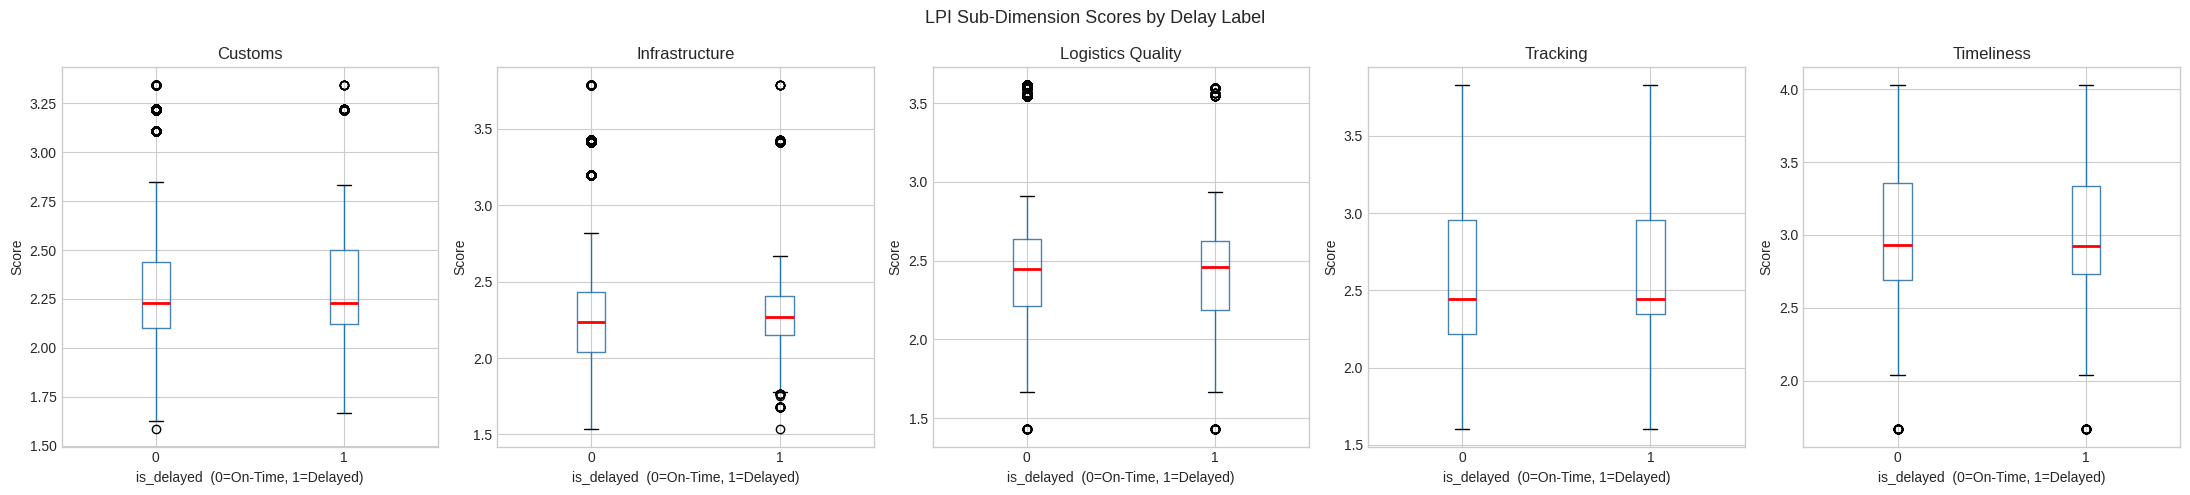

In [46]:
# Boxplots: LPI sub-dimensions by delay label
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, col in zip(axes, LPI_COLS):
    df.boxplot(column=col, by='is_delayed', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('lpi_', '').replace('_', ' ').title())
    ax.set_xlabel('is_delayed  (0=On-Time, 1=Delayed)')
    ax.set_ylabel('Score')

plt.suptitle('LPI Sub-Dimension Scores by Delay Label', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Feature Engineering

We build upon the original feature set with additional LPI-derived features.

### 5a. Time-Based Features

In [47]:
# lead_time_days dropped: PO Sent to Vendor Date is 55.5% null — unreliable.
# procurement_cycle_days dropped: PQ First Sent to Client Date is mostly
# 'Pre-PQ Process' strings → 62.8% null — no usable signal.
# Neither column is computed or imputed.

# Calendar features from Scheduled Delivery Date only
df['scheduled_month']   = df['Scheduled Delivery Date'].dt.month
df['scheduled_quarter'] = df['Scheduled Delivery Date'].dt.quarter
df['scheduled_year']    = df['Scheduled Delivery Date'].dt.year

# Drop all raw date columns and temporary lpi_tier
cols_to_drop = ['Scheduled Delivery Date', 'PO Sent to Vendor Date',
                'PQ First Sent to Client Date', 'lpi_tier']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print('Calendar features created. All date columns dropped.')
print(df[['scheduled_month', 'scheduled_quarter', 'scheduled_year']].describe())


Calendar features created. All date columns dropped.
       scheduled_month  scheduled_quarter  scheduled_year
count      8022.000000        8022.000000     8022.000000
mean          6.390800           2.459362     2011.079282
std           3.299379           1.081762        2.536790
min           1.000000           1.000000     2006.000000
25%           4.000000           2.000000     2009.000000
50%           6.000000           2.000000     2011.000000
75%           9.000000           3.000000     2014.000000
max          12.000000           4.000000     2015.000000


### 5b. Cost / Weight Ratio Features

In [48]:
eps = 1e-6  # avoid division by zero

df['freight_per_kg']    = df['Freight Cost (USD)'] / (df['Weight (Kilograms)'] + eps)
df['value_per_unit']    = df['Line Item Value']     / (df['Line Item Quantity']  + eps)
df['insurance_rate']    = df['Line Item Insurance (USD)'] / (df['Line Item Value'] + eps)

# Log-transforms for heavily right-skewed columns
for col, new_col in [
    ('Freight Cost (USD)',        'log_freight'),
    ('Line Item Value',           'log_line'),
    ('Weight (Kilograms)',        'log_weight'),
    ('freight_per_kg',            'log_freight_per_kg'),
    ('value_per_unit',            'log_value_per_unit'),
]:
    df[new_col] = np.log1p(df[col].clip(lower=0))

print('Cost/weight ratio features and log-transforms created.')

Cost/weight ratio features and log-transforms created.


### 5c. Vendor & Country Delay Rate Encoding

> **Leakage note:** These rates are computed on the full dataset. For rigorous cross-validation, recompute on the training fold only.

In [49]:
print('Vendor and Country columns retained for CV-safe encoding in modelling phase.')
print(f'Unique vendors:   {df["Vendor"].nunique()}')
print(f'Unique countries: {df["Country"].nunique()}')


Vendor and Country columns retained for CV-safe encoding in modelling phase.
Unique vendors:   70
Unique countries: 38


### 5d. LPI-Derived Features

New features that were not possible with the original SCMS-only dataset:

| Feature | Description |
|---|---|
| `lpi_score_zscore` | Z-score of `lpi_score` across all shipments — captures how far a destination country is from the average logistics performance |
| `lpi_hard_infra` | Average of `lpi_customs` + `lpi_infrastructure` — "hard" logistics infrastructure |
| `lpi_soft_infra` | Average of `lpi_logistics_quality` + `lpi_tracking` — "soft" logistics capability |
| `lpi_timeliness_x_intl` | Interaction: timeliness score × international shipments score |
| `lpi_gap_timeliness` | Difference between `lpi_timeliness` and `lpi_score` — countries where timeliness underperforms overall LPI |


In [50]:
# LPI composite features (using the 5 retained sub-dimensions only)
df['lpi_hard_infra'] = (df['lpi_customs'] + df['lpi_infrastructure']) / 2
df['lpi_soft_infra'] = (df['lpi_logistics_quality'] + df['lpi_tracking']) / 2

print('LPI composite features created:')
print(df[['lpi_hard_infra', 'lpi_soft_infra']].describe().round(3))


LPI composite features created:
       lpi_hard_infra  lpi_soft_infra
count        8022.000        8022.000
mean            2.359           2.576
std             0.459           0.525
min             1.625           1.547
25%             2.074           2.188
50%             2.231           2.439
75%             2.426           2.762
max             3.568           3.697


## 6. Encoding & Normalisation

### 6a. One-Hot Encode Categorical Features

In [51]:
numeric_features = [
    # SCMS numeric
    'Unit of Measure (Per Pack)', 'Line Item Quantity', 'Line Item Value',
    'Pack Price', 'Unit Price', 'Weight (Kilograms)',
    'Freight Cost (USD)', 'Line Item Insurance (USD)',
    # Calendar features only (lead_time_days & procurement_cycle_days dropped)
    'scheduled_month', 'scheduled_quarter', 'scheduled_year',
    # Cost/weight ratios & logs
    'freight_per_kg', 'value_per_unit', 'insurance_rate',
    'log_freight', 'log_line', 'log_weight', 'log_freight_per_kg', 'log_value_per_unit',
    # LPI sub-dimensions (5 retained)
    'lpi_customs', 'lpi_infrastructure', 'lpi_logistics_quality',
    'lpi_tracking', 'lpi_timeliness',
    # LPI composite features
    'lpi_hard_infra', 'lpi_soft_infra',
    # EM-DAT disaster severity
    'Disaster_Severity_Index',
]

categorical_features = [
    'Shipment Mode', 'Fulfill Via', 'Managed By', 'Vendor INCO Term',
    'Product Group', 'Sub Classification', 'Dosage Form', 'First Line Designation'
]

numeric_features     = [c for c in numeric_features     if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

y = df['is_delayed'].copy()
X_num = df[numeric_features].copy()
X_cat = df[categorical_features].copy()

X_cat_ohe = pd.get_dummies(X_cat, drop_first=False).astype(int)

X = pd.concat([X_num, X_cat_ohe], axis=1)
print(f'Feature matrix shape: {X.shape}')
print(f'  Numeric features:     {X_num.shape[1]}')
print(f'  OHE features:         {X_cat_ohe.shape[1]}')
print(f'  Missing values in X:  {X.isnull().sum().sum()}')


Feature matrix shape: (8022, 75)
  Numeric features:     27
  OHE features:         48
  Missing values in X:  0


### 6b. Standardise Continuous Features

Apply `StandardScaler` to all continuous/count features (columns with >2 unique values). Binary OHE columns are left as-is.

In [52]:
scale_cols = [c for c in numeric_features if X[c].nunique() > 2]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'Features scaled:  {len(scale_cols)}')
print(f'Total features:   {X_scaled.shape[1]}')
print(f'Total samples:    {X_scaled.shape[0]}')

Features scaled:  27
Total features:   75
Total samples:    8022


## 7. Final Dataset Summary & Export

In [53]:
print('=' * 60)
print('FINAL PREPROCESSED DATASET SUMMARY (SCMS + LPI + EM-DAT)')
print('=' * 60)
print(f'Samples:           {X_scaled.shape[0]}')
print(f'Features:          {X_scaled.shape[1]}')
print(f'Target (Delayed):  {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Target (On-Time):  {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')
print(f'Missing values:    {X_scaled.isnull().sum().sum()}')
print('=' * 60)

print('\nFeature list:')
for i, col in enumerate(X_scaled.columns, 1):
    print(f'  {i:3}. {col}')


FINAL PREPROCESSED DATASET SUMMARY (SCMS + LPI + EM-DAT)
Samples:           8022
Features:          75
Target (Delayed):  935 (11.7%)
Target (On-Time):  7087 (88.3%)
Missing values:    0

Feature list:
    1. Unit of Measure (Per Pack)
    2. Line Item Quantity
    3. Line Item Value
    4. Pack Price
    5. Unit Price
    6. Weight (Kilograms)
    7. Freight Cost (USD)
    8. Line Item Insurance (USD)
    9. scheduled_month
   10. scheduled_quarter
   11. scheduled_year
   12. freight_per_kg
   13. value_per_unit
   14. insurance_rate
   15. log_freight
   16. log_line
   17. log_weight
   18. log_freight_per_kg
   19. log_value_per_unit
   20. lpi_customs
   21. lpi_infrastructure
   22. lpi_logistics_quality
   23. lpi_tracking
   24. lpi_timeliness
   25. lpi_hard_infra
   26. lpi_soft_infra
   27. Disaster_Severity_Index
   28. Shipment Mode_Air
   29. Shipment Mode_Air Charter
   30. Shipment Mode_Ocean
   31. Shipment Mode_Truck
   32. Fulfill Via_Direct Drop
   33. Fulfill Via_

In [54]:
# Scaled version (for Logistic Regression, Naive Bayes, SVM)
X_scaled_out = X_scaled.copy()
X_scaled_out['is_delayed'] = y.values
scaled_path = os.path.join(OUTPUT_DIR, 'preprocessed_scms_lpi_emdat.csv')
X_scaled_out.to_csv(scaled_path, index=False)
print(f'Scaled dataset saved to:\n  {scaled_path}')

# Unscaled version (for Decision Tree, Random Forest, XGBoost)
X_unscaled_out = X.copy()
X_unscaled_out['is_delayed'] = y.values
unscaled_path = os.path.join(OUTPUT_DIR, 'preprocessed_scms_lpi_emdat_unscaled.csv')
X_unscaled_out.to_csv(unscaled_path, index=False)
print(f'Unscaled dataset saved to:\n  {unscaled_path}')


Scaled dataset saved to:
  /content/drive/MyDrive/Semester 4/MLPR/MLPR Project/preprocessed_scms_lpi_emdat.csv
Unscaled dataset saved to:
  /content/drive/MyDrive/Semester 4/MLPR/MLPR Project/preprocessed_scms_lpi_emdat_unscaled.csv


---
## Notes for Modelling Phase

1. **Class Imbalance (~11.5% delayed):** Consider SMOTE or `class_weight='balanced'` in classifiers. Evaluate with F1/AUC-ROC rather than accuracy alone.

2. **Vendor/Country leakage:** `vendor_delay_rate` and `country_delay_rate` are computed on the full dataset. For rigorous cross-validation, recompute these on the training fold only inside the CV loop.

3. **LPI leakage check:** LPI scores were matched using only the most recent prior survey year, so they do not encode future data. No leakage concern.

4. **LPI missing indicator (`lpi_missing`):** ~8 countries had no LPI data; their LPI features were imputed with column-wise medians. The indicator flag allows tree-based models to learn a distinct split for these.

5. **Multicollinearity among LPI sub-dimensions:** LPI sub-scores are highly correlated (they reflect the same underlying country logistics quality). For Logistic Regression, consider using only `lpi_score` (overall) plus `lpi_timeliness`, or apply PCA on the LPI block. Tree-based models are robust to this.

6. **Saved files (in MLPR Project folder on Google Drive):**
   - `preprocessed_scms_lpi.csv` — standardised (for LR, Naive Bayes, SVM)
   - `preprocessed_scms_lpi_unscaled.csv` — raw values (for Decision Tree, Random Forest)